In [33]:
from functools import partial

import matplotlib.pyplot as plt

from superfv import EulerSolver
from superfv.initial_conditions import entropy_wave

In [34]:
sim0 = EulerSolver(
    ic=partial(entropy_wave, gamma=5 / 3),
    gamma=5 / 3,
    nx=32,
    p=3,
)
sim1 = EulerSolver(
    ic=partial(entropy_wave, gamma=5 / 3),
    gamma=5 / 3,
    nx=32,
    p=3,
    ZS=True,
    SED=True,
    PAD={"rho": (0, None), "P": (0, None)},
    lazy_primitives="none",
)
sim2 = EulerSolver(
    ic=partial(entropy_wave, gamma=5 / 3),
    gamma=5 / 3,
    nx=32,
    p=3,
    ZS=True,
    SED=True,
    PAD={"rho": (0, None), "P": (0, None)},
    lazy_primitives="full",
)

sim0.run(n=1, q_max=0, snapshot_mode="none")
sim1.run(n=1, q_max=0, snapshot_mode="none")
sim2.run(n=1, q_max=0, snapshot_mode="none")

Step #1 @ t=1.25e-02 | dt=1.25e-02 | min(rho)=1.00e+00, min(P)=6.00e-01 | E_cons=5.28e+01 | (ran in 0.00s)
Step #1 @ t=1.25e-02 | dt=1.25e-02 | min(rho)=1.00e+00, min(P)=6.00e-01 | E_cons=nan | (ran in 0.00s)
Step #1 @ t=1.25e-02 | dt=1.25e-02 | min(rho)=1.00e+00, min(P)=6.00e-01 | E_cons=nan | (ran in 0.00s)


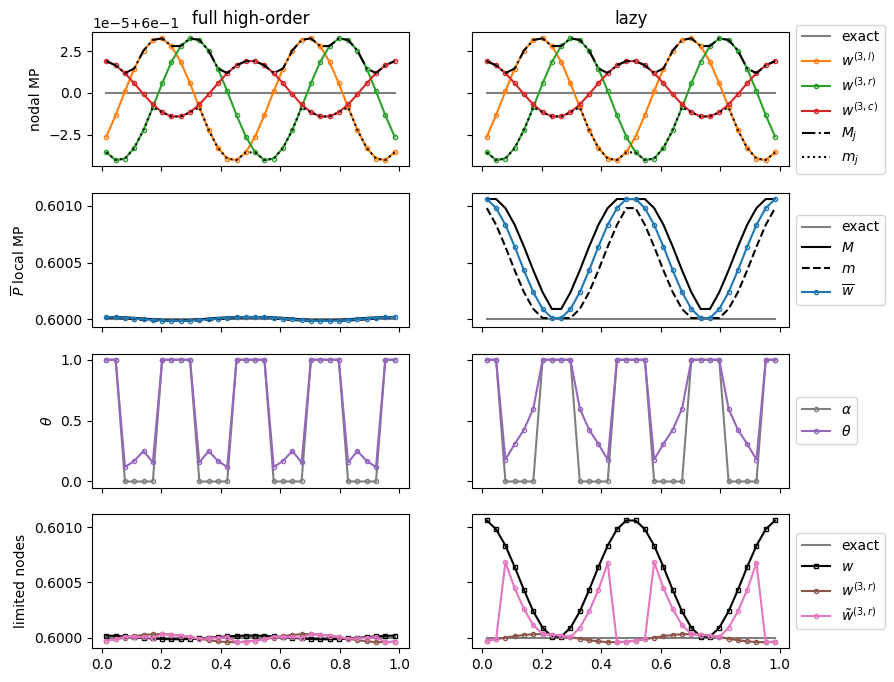

In [35]:
fig, axs = plt.subplots(4, 2, sharex=True, sharey="row", figsize=(9, 8))

axs[0, 0].set_title("full high-order")
axs[0, 1].set_title("lazy")

axs[0, 0].set_ylabel("nodal MP")
axs[1, 0].set_ylabel(r"$\overline{P}$ local MP")
axs[2, 0].set_ylabel(r"$\theta$")
axs[3, 0].set_ylabel("limited nodes")

cmap = plt.get_cmap("tab10")

for j in (0, 1):
    axs[0, j].plot(
        sim0.mesh.x_centers, sim0.mesh.nx * [3 / 5], label=r"exact", color="grey"
    )
    axs[0, j].plot(
        sim0.mesh.x_centers,
        sim0.arrays["_x_nodes_"][sim0.interior][4, :, 0, 0, 0],
        label=r"$w^{(3,l)}$",
        marker="o",
        mfc="none",
        markersize=3,
        color=cmap(1),
    )
    axs[0, j].plot(
        sim0.mesh.x_centers,
        sim0.arrays["_x_nodes_"][sim0.interior][4, :, 0, 0, 1],
        label=r"$w^{(3,r)}$",
        marker="o",
        mfc="none",
        markersize=3,
        color=cmap(2),
    )
    axs[0, j].plot(
        sim0.mesh.x_centers,
        sim0.arrays["_wcc_"][sim0.interior][4, :, 0, 0],
        label=r"$w^{(3,c)}$",
        marker="o",
        mfc="none",
        markersize=3,
        color=cmap(3),
    )
    axs[0, j].plot(
        sim1.mesh.x_centers,
        sim1.arrays["_Mj_"][sim1.interior][4, :, 0, 0],
        label=r"$M_j$",
        color="k",
        linestyle="dashdot",
    )
    axs[0, j].plot(
        sim1.mesh.x_centers,
        sim1.arrays["_mj_"][sim1.interior][4, :, 0, 0],
        label=r"$m_j$",
        color="k",
        linestyle="dotted",
    )

for j, sim in enumerate((sim1, sim2)):
    axs[1, j].plot(
        sim.mesh.x_centers, sim.mesh.nx * [3 / 5], label=r"exact", color="grey"
    )
    axs[1, j].plot(
        sim.mesh.x_centers,
        sim.arrays["_M_"][sim.interior][4, :, 0, 0],
        label=r"$M$",
        color="k",
    )
    axs[1, j].plot(
        sim.mesh.x_centers,
        sim.arrays["_m_"][sim.interior][4, :, 0, 0],
        label=r"$m$",
        color="k",
        linestyle="--",
    )
    axs[1, j].plot(
        sim.mesh.x_centers,
        sim.arrays["_w_"][sim.interior][4, :, 0, 0],
        label=r"$\overline{w}$",
        marker="o",
        mfc="none",
        markersize=3,
        color=cmap(0),
    )

    axs[2, j].plot(
        sim.mesh.x_centers,
        sim.arrays["_alpha_"][sim.interior][4, :, 0, 0],
        label=r"$\alpha$",
        marker="o",
        mfc="none",
        markersize=3,
        color=cmap(7),
    )
    axs[2, j].plot(
        sim.mesh.x_centers,
        sim.arrays["_theta_"][sim.interior][4, :, 0, 0],
        label=r"$\theta$",
        marker="o",
        mfc="none",
        markersize=3,
        color=cmap(4),
    )

    axs[3, j].plot(
        sim.mesh.x_centers, sim.mesh.nx * [3 / 5], label=r"exact", color="grey"
    )
    axs[3, j].plot(
        sim.mesh.x_centers,
        sim.arrays["_w_"][sim.interior][4, :, 0, 0],
        label=r"$w$",
        marker="s",
        mfc="none",
        markersize=3,
        color="k",
    )
    axs[3, j].plot(
        sim0.mesh.x_centers,
        sim0.arrays["_x_nodes_"][sim0.interior][4, :, 0, 0, 0],
        label=r"$w^{(3,r)}$",
        marker="o",
        mfc="none",
        markersize=3,
        color=cmap(5),
    )
    axs[3, j].plot(
        sim.mesh.x_centers,
        sim.arrays["_x_nodes_"][sim.interior][4, :, 0, 0, 0],
        label=r"$\tilde{w}^{(3,r)}$",
        marker="o",
        mfc="none",
        markersize=3,
        color=cmap(6),
    )

axs[2, 0].set_ylim(-0.05, 1.05)
axs[0, 1].legend(loc="center left", bbox_to_anchor=(1, 0.5))
axs[1, 1].legend(loc="center left", bbox_to_anchor=(1, 0.5))
axs[2, 1].legend(loc="center left", bbox_to_anchor=(1, 0.5))
axs[3, 1].legend(loc="center left", bbox_to_anchor=(1, 0.5))

In [36]:
fig.savefig(
    "/Users/jonathan/Desktop/1d-entropy-wave_1-substep.png", bbox_inches="tight"
)